# LSTM Time Series Forecasting

---

This notebook demonstrates LSTM as the deep learning alternative to ARIMA.

| Section | What we do |
|---------|------------|
| 1 | Load data & stationarity check |
| 2 | Scale prices and create sequences |
| 3 | Build and train the LSTM model |
| 4 | Forecast prices with confidence cone |
| 5 | Evaluate: MAE, RMSE, MAPE |
| 6 | **Model comparison: ARIMA vs LSTM** |

### LSTM vs ARIMA — key difference in input

| | ARIMA | LSTM |
|--|-------|------|
| Input data | **Daily returns** (must be stationary) | **Scaled prices** (LSTM handles trends) |
| Why | ARIMA's math breaks on non-stationary series | LSTM's gating learns trends from price sequences |
| Output | Forecasted return → compound to price | Forecasted price directly |
| Compounding needed? | Yes | **No** |

The key insight: ARIMA needs returns because the formula assumes a stable mean.
LSTM has a memory cell that *learns* how prices drift — so we feed it the full price trajectory,
scaled to [0, 1], and the model outputs tomorrow's scaled price directly.

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.stattools import adfuller
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi']        = 120
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

# ── Configuration ────────────────────────────────────────────
TICKER      = 'TSLA'
ALL_TICKERS = ['TSLA', 'BND', 'SPY']
START_DATE  = '2015-01-01'
END_DATE    = '2026-06-30'
TRAIN_END   = '2024-12-31'
WINDOW_SIZE = 60    # past 60 days of prices used to predict the next price
EPOCHS      = 50
BATCH_SIZE  = 32

print(f'Ticker      : {TICKER}')
print(f'Window size : {WINDOW_SIZE} days')
print(f'Epochs      : {EPOCHS} (EarlyStopping will stop sooner if needed)')
print(f'Batch size  : {BATCH_SIZE}')

Ticker      : TSLA
Window size : 60 days
Epochs      : 50 (EarlyStopping will stop sooner if needed)
Batch size  : 32


---
## Section 1 — Load Data & Stationarity Check

We run the ADF test to confirm that raw prices are non-stationary.
This is the same finding as in the ARIMA notebook — but here we will handle it
differently: instead of differencing (returns), we **scale prices** to [0, 1].

In [3]:
raw   = yf.download(TICKER, start=START_DATE, end=END_DATE, auto_adjust=True)
price = raw['Close'].squeeze()

print(f'Loaded {len(price)} trading days')
print(f'Date range : {price.index.min().date()} → {price.index.max().date()}')

# ADF test
def adf_test(series, name):
    res = adfuller(series.dropna())
    verdict = 'STATIONARY ✅' if res[1] < 0.05 else 'NON-STATIONARY ❌'
    print(f'  {name:<20} p={res[1]:.6f}  → {verdict}')

returns = price.pct_change().dropna()
print('\nADF Test:')
adf_test(price,   'TSLA Price')
adf_test(returns, 'TSLA Returns')

print()
print('ARIMA approach: convert to RETURNS (stationary) → forecast return → compound to price')
print('LSTM approach : scale PRICES to [0,1] → forecast next scaled price → inverse-scale')
print('→ LSTM never needs the compounding step, so no exponential drift.')

[*********************100%***********************]  1 of 1 completed


Loaded 2888 trading days
Date range : 2015-01-02 → 2026-06-29

ADF Test:
  TSLA Price           p=0.727042  → NON-STATIONARY ❌
  TSLA Returns         p=0.000000  → STATIONARY ✅

ARIMA approach: convert to RETURNS (stationary) → forecast return → compound to price
LSTM approach : scale PRICES to [0,1] → forecast next scaled price → inverse-scale
→ LSTM never needs the compounding step, so no exponential drift.


---
## Section 2 — Prepare Data for LSTM

### Step A — Scale prices to [0, 1]

MinMaxScaler maps the training price range to [0, 1]:
```
scaled = (price - min_train) / (max_train - min_train)
```

**Important rule**: fit the scaler ONLY on training data.
If we used the test period's max/min, the model would 'see the future' — data leakage.

### Step B — Create sequences

The same idea as before, but on prices instead of returns:
```
X[0] = [price_1, price_2, ..., price_60]  →  y[0] = price_61
X[1] = [price_2, price_3, ..., price_61]  →  y[1] = price_62
```
The model learns: given the last 60 days of scaled prices, predict tomorrow's scaled price.
LSTM can't just look at one day's price and predict tomorrow. It needs to see a sequence of past days to learn patterns. Creating sequences is how we restructure the data into that format.

In [4]:
train_price = price.loc[:TRAIN_END]
test_price  = price.loc[TRAIN_END:].iloc[1:]   # strictly after train end

print(f'Train : {len(train_price)} days  ({train_price.index[0].date()} → {train_price.index[-1].date()})')
print(f'Test  : {len(test_price)} days  ({test_price.index[0].date()} → {test_price.index[-1].date()})')

Train : 2516 days  (2015-01-02 → 2024-12-31)
Test  : 372 days  (2025-01-02 → 2026-06-29)


In [5]:
# Fit scaler on training prices ONLY
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_price.values.reshape(-1, 1))

# Apply same scale to test prices (no fitting — avoids data leakage)
test_scaled  = scaler.transform(test_price.values.reshape(-1, 1))

print(f'Training price range : ${train_price.min():.2f} → ${train_price.max():.2f}')
print(f'After scaling        : {train_scaled.min():.4f} → {train_scaled.max():.4f}')
print()
print('Test prices are scaled using the TRAINING min/max.')
print('If the test price exceeds the training max, the scaled value will be > 1 — that is OK.')

Training price range : $9.58 → $479.86
After scaling        : 0.0000 → 1.0000

Test prices are scaled using the TRAINING min/max.
If the test price exceeds the training max, the scaled value will be > 1 — that is OK.


In [6]:
def create_sequences(data, window_size):
    """Convert a 1-D scaled array into (X, y) supervised pairs."""
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i - window_size : i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

# Training sequences (only on training data)
X_train, y_train = create_sequences(train_scaled, WINDOW_SIZE)

# Test sequences:
# We need the last WINDOW_SIZE training prices as context for the first test prediction
last_train_window = train_scaled[-WINDOW_SIZE:]           # last 60 training days
combined_test     = np.concatenate([last_train_window, test_scaled], axis=0)
X_test, y_test    = create_sequences(combined_test, WINDOW_SIZE)
# X_test[0]  = last 60 training days → predicts test day 1 price
# X_test[1]  = last 59 training days + test day 1 → predicts test day 2 price
# ... and so on

# Reshape to [samples, timesteps, features] — required by Keras LSTM
X_train = X_train.reshape(-1, WINDOW_SIZE, 1)
X_test  = X_test.reshape(-1,  WINDOW_SIZE, 1)

print(f'X_train : {X_train.shape}   (samples × timesteps × features)')
print(f'X_test  : {X_test.shape}')
print(f'y_train : {y_train.shape}')
print()
print(f'Note: X_test has {X_test.shape[0]} rows, matching the {len(test_price)} test days.')

X_train : (2456, 60, 1)   (samples × timesteps × features)
X_test  : (372, 60, 1)
y_train : (2456,)

Note: X_test has 372 rows, matching the 372 test days.


---
## Section 3 — Build & Train the LSTM Model

### Architecture

```
Input: (60, 1)      ← 60 days of scaled prices, 1 feature per day
     ↓
 LSTM(64 units)     ← learns price patterns across 60-day windows
     ↓
 Dropout(0.2)       ← regularization: prevents memorising training patterns
     ↓
 Dense(1)           ← outputs one number: tomorrow's scaled price
```

### EarlyStopping
We monitor validation loss and stop training when it stops improving (patience=10).
`restore_best_weights=True` means after stopping, we keep the best epoch's weights.

In [7]:
model = Sequential([
    LSTM(64, activation='tanh', input_shape=(WINDOW_SIZE, 1)),
    Dropout(0.2),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

print(f'\nTraining stopped at epoch {len(history.history["loss"])}/{EPOCHS}')

Epoch 1/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0088 - val_loss: 0.0024
Epoch 2/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.0016 - val_loss: 0.0041
Epoch 3/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.0015 - val_loss: 0.0020
Epoch 4/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0013 - val_loss: 0.0019
Epoch 5/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0012 - val_loss: 0.0020
Epoch 6/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0011 - val_loss: 0.0018
Epoch 7/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 9.5901e-04 - val_loss: 0.0016
Epoch 8/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 9.5106e-04 - val_loss: 0.0015
Epoch 9/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 8.9387e-04 - val_loss: 0.0014
Epoch 10/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 8.7491e-04 - val_loss: 0.0013
Epoch 11/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 8.1259e-04 - val_loss: 0.0015
Epoch 12/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 2

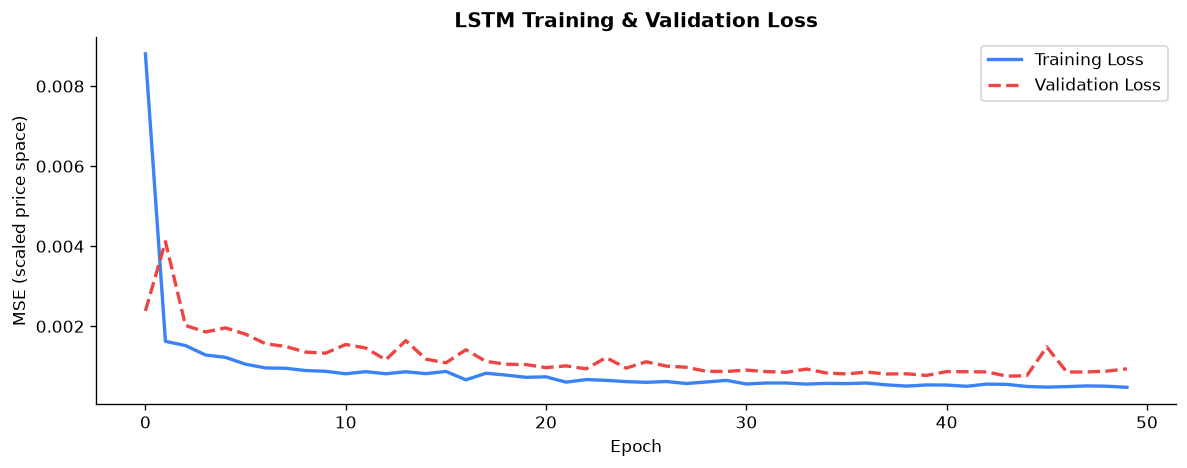

Interpretation:
  ✅ Both lines decrease and converge     → good learning, no overfitting
  ❌ Val loss rises while train falls      → overfitting — add more Dropout
  ❌ Both lines flat from epoch 1          → model learns nothing (common for noisy assets)


In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history.history['loss'],     color='#3B82F6', lw=2, label='Training Loss')
ax.plot(history.history['val_loss'], color='#EF4444', lw=2, label='Validation Loss', linestyle='--')
ax.set_title('LSTM Training & Validation Loss', fontsize=12, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE (scaled price space)')
ax.legend()
plt.tight_layout()
plt.show()

print('Interpretation:')
print('  ✅ Both lines decrease and converge     → good learning, no overfitting')
print('  ❌ Val loss rises while train falls      → overfitting — add more Dropout')
print('  ❌ Both lines flat from epoch 1          → model learns nothing (common for noisy assets)')

---
## Section 4 — Forecast Prices

The LSTM predicts **scaled prices** directly.
We then apply `scaler.inverse_transform()` to convert back to real dollar values.

**No compounding needed** — the model already predicts prices, not returns.

For the confidence cone, we use the same √t approach:
```
price_cone[t] = last_train_price × σ_daily × √t
```
where σ_daily is the daily return standard deviation from the training period.
This represents how far prices can randomly walk away from the central forecast.

In [10]:
# Predict scaled prices on the test set
y_pred_scaled = model.predict(X_test, verbose=0)     # shape: (N_test, 1)

# Inverse-transform back to real prices
fc_prices = scaler.inverse_transform(y_pred_scaled).flatten()  # shape: (N_test,)

print(f'Forecast range : ${fc_prices.min():.2f} → ${fc_prices.max():.2f}')
print(f'Actual range   : ${test_price.min():.2f} → ${test_price.max():.2f}')

Forecast range : $233.42 → $474.48
Actual range   : $221.86 → $489.88


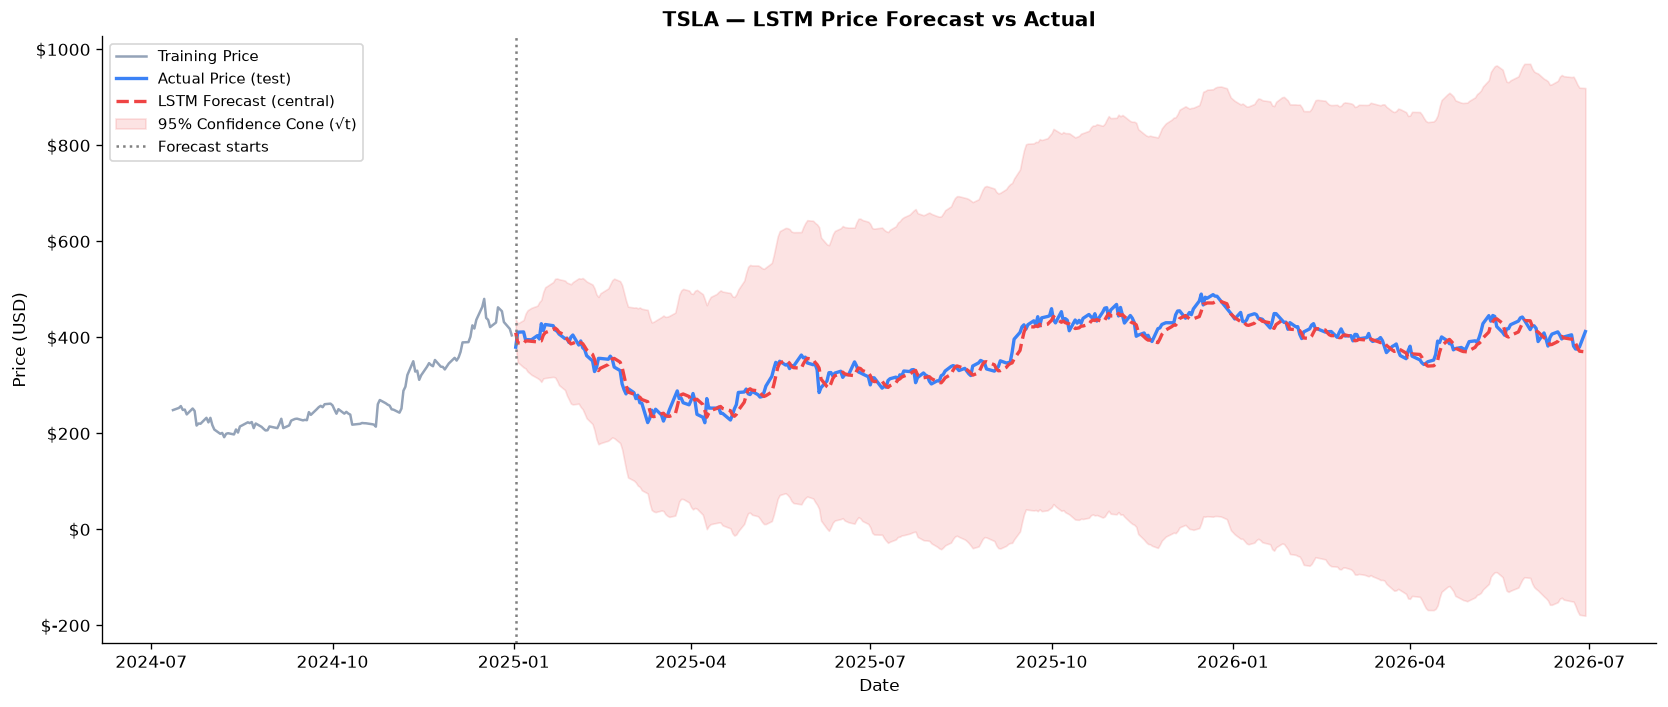

Last training price : $403.84
Day-1 cone width    : ±$28.50  (95% band)
Day-372 cone width   : ±$549.72 (95% band)


In [11]:
# ── 95% Confidence Cone (√t scaling) ──
daily_std        = float(returns.loc[:TRAIN_END].std())
last_train_price = float(train_price.iloc[-1])
days_ahead       = np.arange(1, len(fc_prices) + 1)
price_cone       = last_train_price * daily_std * np.sqrt(days_ahead)

fc_upper = fc_prices + 1.96 * price_cone
fc_lower = fc_prices - 1.96 * price_cone

test_idx = test_price.index[:len(fc_prices)]

fig, ax = plt.subplots(figsize=(14, 6))

# Last 120 training days for context
hist = train_price.iloc[-120:]
ax.plot(hist.index, hist.values, color='#94A3B8', lw=1.5, label='Training Price')

# Actual test prices
ax.plot(test_price.index, test_price.values,
        color='#3B82F6', lw=2.0, label='Actual Price (test)')

# LSTM forecast (central)
ax.plot(test_idx, fc_prices,
        color='#EF4444', lw=2.0, linestyle='--', label='LSTM Forecast (central)')

# 95% confidence cone
ax.fill_between(test_idx, fc_lower, fc_upper,
                alpha=0.15, color='#EF4444', label='95% Confidence Cone (√t)')

ax.axvline(test_idx[0], color='gray', lw=1.5, linestyle=':', label='Forecast starts')
ax.set_title(f'{TICKER} — LSTM Price Forecast vs Actual', fontsize=12, fontweight='bold')
ax.set_ylabel('Price (USD)')
ax.set_xlabel('Date')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'${y:.0f}'))
ax.legend(fontsize=9, loc='upper left')
plt.tight_layout()
plt.show()

print(f'Last training price : ${last_train_price:.2f}')
print(f'Day-1 cone width    : ±${1.96*price_cone[0]:.2f}  (95% band)')
print(f'Day-{len(fc_prices)} cone width   : ±${1.96*price_cone[-1]:.2f} (95% band)')

---
## Section 5 — Evaluate Accuracy

The LSTM forecast here is a **one-step-ahead evaluation**: each prediction uses
the 60 actual (observed) days before it, not the previous predictions.
This is the correct way to evaluate a model on historical test data.

In [12]:
fc_series     = pd.Series(fc_prices, index=test_idx)
actual_series = test_price.reindex(test_idx).dropna()
fc_aligned    = fc_series.reindex(actual_series.index)

lstm_mae  = mean_absolute_error(actual_series, fc_aligned)
lstm_rmse = np.sqrt(mean_squared_error(actual_series, fc_aligned))
lstm_mape = np.mean(np.abs((actual_series - fc_aligned) / actual_series)) * 100

print('='*45)
print('  LSTM Forecast Metrics — TSLA')
print('='*45)
print(f'  MAE  : ${lstm_mae:.2f}')
print(f'  RMSE : ${lstm_rmse:.2f}')
print(f'  MAPE : {lstm_mape:.2f}%')
print()
print('MAPE interpretation:')
print('  < 10%  → excellent')
print('  10-20% → acceptable for volatile stocks')
print('  > 30%  → model is not tracking prices well')

  LSTM Forecast Metrics — TSLA
  MAE  : $11.87
  RMSE : $15.10
  MAPE : 3.31%

MAPE interpretation:
  < 10%  → excellent
  10-20% → acceptable for volatile stocks
  > 30%  → model is not tracking prices well
